In [6]:
import numpy as np
import matplotlib.pyplot as plt
import ripser
import persim
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
import gudhi as gd
from gudhi.representations import Landscape, Silhouette, PersistenceImage
import tadasets
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import networkx as nx
import nibabel as nib
import os
from tqdm import tqdm
from skimage.transform import resize
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, roc_curve
import warnings
import time
from scipy.linalg import svd
import pydicom
from pathlib import Path
from PIL import Image
import glob
from scipy.ndimage import gaussian_filter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from scipy.ndimage import gaussian_filter, binary_dilation, binary_closing, binary_fill_holes
from skimage import exposure, morphology, segmentation, measure
import torch.nn.functional as F
from torchvision import models
warnings.filterwarnings("ignore", category=UserWarning)

target_shape = (128, 128, 64)

In [2]:
def load_custom_dataset(base_path, max_samples=None):
    tumor_dir = os.path.join(base_path, "Tumor")
    mask_dir = os.path.join(base_path, "Mask")
    
    tumor_files = sorted(glob.glob(os.path.join(tumor_dir, "*.tif")))
    mask_files = sorted(glob.glob(os.path.join(mask_dir, "*.tif")))
    
    if max_samples is not None:
        tumor_files = tumor_files[:max_samples]
        mask_files = mask_files[:max_samples]
    
    tumor_images = []
    mask_images = []
    
    for tumor_file, mask_file in zip(tumor_files, mask_files):
        tumor_img = np.array(Image.open(tumor_file))
        mask_img = np.array(Image.open(mask_file))
        
        if not (np.array_equal(np.unique(mask_img), [0, 1]) or mask_img.dtype == bool):
            mask_img = mask_img > 0
        
        tumor_images.append(tumor_img)
        mask_images.append(mask_img)
    
    return np.array(tumor_images), np.array(mask_images)

In [3]:
def dice_loss(pred, target):
    smooth = 1.0
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    return 1 - (2.0 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)

def iou_score(pred, target):
    pred = (pred > 0.5).float()
    target = target.float()
    
    intersection = (pred * target).sum().item()
    union = (pred + target).clamp(0, 1).sum().item()
    
    if union < 1e-6:
        return 0
    return intersection / union

def calculate_iou(true_mask, pred_mask):
    true_mask = true_mask.astype(bool)
    pred_mask = pred_mask.astype(bool)
    
    intersection = np.logical_and(true_mask, pred_mask)
    union = np.logical_or(true_mask, pred_mask)
    
    if np.sum(union) > 0:
        iou = np.sum(intersection) / np.sum(union)
    else:
        iou = 0.0
    
    return iou

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=20, device='cuda', is_enhanced=False):
    model.to(device)
    best_val_iou = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_iou': [], 'val_iou': []}
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_iou = 0.0
        
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Train)"):
            if is_enhanced:
                images = batch['image'].to(device)
                features = batch['features'].to(device)
                masks = batch['mask'].to(device).unsqueeze(1)
                
                optimizer.zero_grad()
                outputs = model(images, features)
            else:
                images = batch['image'].to(device)
                masks = batch['mask'].to(device).unsqueeze(1)
                
                optimizer.zero_grad()
                outputs = model(images)
            
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_iou += iou_score(outputs, masks)
            
        train_loss /= len(train_loader)
        train_iou /= len(train_loader)
        
        model.eval()
        val_loss = 0.0
        val_iou = 0.0
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Val)"):
                if is_enhanced:
                    images = batch['image'].to(device)
                    features = batch['features'].to(device)
                    masks = batch['mask'].to(device).unsqueeze(1)
                    
                    outputs = model(images, features)
                else:
                    images = batch['image'].to(device)
                    masks = batch['mask'].to(device).unsqueeze(1)
                    
                    outputs = model(images)
                
                loss = criterion(outputs, masks)
                val_loss += loss.item()
                val_iou += iou_score(outputs, masks)
                
        val_loss /= len(val_loader)
        val_iou /= len(val_loader)
        
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_iou'].append(train_iou)
        history['val_iou'].append(val_iou)
        
        if val_iou > best_val_iou:
            best_val_iou = val_iou
            model_name = 'models/enhanced_unet.pth' if is_enhanced else 'models/standard_unet.pth'
            torch.save(model.state_dict(), model_name)
            print(f"Saved best model with IoU score: {val_iou:.4f}")
    
    return model, history

In [4]:
class BrainTumorDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]
        
        if len(image.shape) == 2:
            image = np.stack([image] * 3, axis=2)
            
        image = image.astype(np.float32) / 255.0
        
        image = torch.from_numpy(image.transpose(2, 0, 1)).float()
        mask = torch.from_numpy(mask.astype(np.float32))
        
        return {'image': image, 'mask': mask}

class EnhancedBrainTumorDataset(Dataset):
    def __init__(self, images, feature_maps, masks, transform=None):
        self.images = images
        self.feature_maps = feature_maps
        self.masks = masks
        self.transform = transform
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        feature_map = self.feature_maps[idx]
        mask = self.masks[idx]
        
        if len(image.shape) == 2:
            image = np.stack([image] * 3, axis=2)
            
        image = image.astype(np.float32) / 255.0
        feature_map = feature_map.astype(np.float32)
        
        image = torch.from_numpy(image.transpose(2, 0, 1)).float()
        feature_map = torch.from_numpy(feature_map).float().unsqueeze(0)  
        mask = torch.from_numpy(mask.astype(np.float32))
        
        return {'image': image, 'features': feature_map, 'mask': mask}

In [5]:
def compute_fiber_bundle_features(images, patch_size=7, stride=4, n_neighbors=10):
    """
    Вычисляет признаки на основе расслоения (fiber bundle) для создания карт аномалий
    """
    all_feature_maps = []
    
    for img_idx, image in enumerate(tqdm(images, desc="Computing features")):
        h, w = image.shape[:2]
        
        # Подготовка патчей
        patches = []
        positions = []
        
        for i in range(0, h - patch_size + 1, stride):
            for j in range(0, w - patch_size + 1, stride):
                patch = image[i:i+patch_size, j:j+patch_size]
                patches.append(patch.flatten())
                positions.append((i, j))
        
        patches = np.array(patches)
        
        # Вычисляем kNN для патчей
        nbrs = NearestNeighbors(n_neighbors=n_neighbors+1).fit(patches)
        distances, indices = nbrs.kneighbors(patches)
        indices = indices[:, 1:] 
        
        # Вычисляем кривизну
        curvature_scores = np.zeros(len(patches))
        
        for i in range(len(patches)):
            neighbors = patches[indices[i]]
            center = patches[i]
            centered_neighbors = neighbors - center
            
            cov_matrix = np.dot(centered_neighbors.T, centered_neighbors)
            eigenvalues = np.linalg.eigvalsh(cov_matrix)
            eigenvalues = eigenvalues[eigenvalues > 1e-10]
            
            if len(eigenvalues) > 1:
                min_eigenvalue = np.min(eigenvalues)
                max_eigenvalue = np.max(eigenvalues)
                curvature_scores[i] = 1.0 - (min_eigenvalue / max_eigenvalue)
            else:
                curvature_scores[i] = 1.0

        if np.max(curvature_scores) > np.min(curvature_scores):
            curvature_scores = (curvature_scores - np.min(curvature_scores)) / (np.max(curvature_scores) - np.min(curvature_scores))
        
        curvature_map = np.zeros((h, w))
        count_map = np.zeros((h, w))
        
        for score, (i, j) in zip(curvature_scores, positions):
            curvature_map[i:i+patch_size, j:j+patch_size] += score
            count_map[i:i+patch_size, j:j+patch_size] += 1
        
        count_map[count_map == 0] = 1
        curvature_map = curvature_map / count_map
        
        curvature_map = gaussian_filter(curvature_map, sigma=1.0)
        
        # Нормализуем в диапазон [0, 1]
        if np.max(curvature_map) > np.min(curvature_map):
            curvature_map = (curvature_map - np.min(curvature_map)) / (np.max(curvature_map) - np.min(curvature_map))
            
        all_feature_maps.append(curvature_map)
    
    return np.array(all_feature_maps)

In [7]:
def visualize_comparison(tumor_images, true_masks, standard_masks, enhanced_masks, 
                         standard_ious, enhanced_ious):
    n_images = len(tumor_images)
    
    plt.figure(figsize=(15, 5*n_images))
    
    for i in range(n_images):
        # Оригинальное изображение
        plt.subplot(n_images, 4, i*4 + 1)
        plt.imshow(tumor_images[i], cmap='gray')
        plt.title(f"Исходное изображение {i+1}")
        plt.axis('off')
        
        # Истинная маска
        plt.subplot(n_images, 4, i*4 + 2)
        plt.imshow(tumor_images[i], cmap='gray')
        plt.imshow(true_masks[i], alpha=0.5, cmap='hot')
        plt.title(f"Истинная маска {i+1}")
        plt.axis('off')
        
        # Стандартная модель
        plt.subplot(n_images, 4, i*4 + 3)
        plt.imshow(tumor_images[i], cmap='gray')
        plt.imshow(standard_masks[i], alpha=0.5, cmap='hot')
        plt.title(f"Стандартная U-Net (IoU: {standard_ious[i]:.4f})")
        plt.axis('off')
        
        # Расширенная модель
        plt.subplot(n_images, 4, i*4 + 4)
        plt.imshow(tumor_images[i], cmap='gray')
        plt.imshow(enhanced_masks[i], alpha=0.5, cmap='hot')
        plt.title(f"U-Net + Геом/Топол (IoU: {enhanced_ious[i]:.4f})")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    mean_standard_iou = np.mean(standard_ious)
    mean_enhanced_iou = np.mean(enhanced_ious)
    
    improvement = (mean_enhanced_iou - mean_standard_iou) / mean_standard_iou * 100
    
    plt.figure(figsize=(8, 6))
    plt.bar(['Стандартная U-Net', 'U-Net + Геом/Топол'], 
            [mean_standard_iou, mean_enhanced_iou], 
            color=['royalblue', 'forestgreen'])
    plt.ylabel('Средний IoU')
    plt.title(f'Сравнение производительности моделей\nУлучшение: {improvement:.2f}%')
    
    for i, v in enumerate([mean_standard_iou, mean_enhanced_iou]):
        plt.text(i, v + 0.01, f'{v:.4f}', ha='center')
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    plt.figure(figsize=(10, 6))
    
    iou_diffs = [enhanced - standard for enhanced, standard in zip(enhanced_ious, standard_ious)]
    colors = ['green' if diff > 0 else 'red' for diff in iou_diffs]
    
    plt.bar(range(len(iou_diffs)), iou_diffs, color=colors)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    plt.xlabel('Индекс изображения')
    plt.ylabel('Прирост IoU (Enhanced - Standard)')
    plt.title('Прирост IoU при использовании топологических/геометрических признаков')
    plt.xticks(range(len(iou_diffs)))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    for i, v in enumerate(iou_diffs):
        plt.text(i, v + 0.01 if v >= 0 else v - 0.03, f'{v:.4f}', ha='center')

    plt.show()


In [8]:
def post_process_masks(pred_masks, true_masks=None, lower_percentile=85, iterations=2):
    processed_masks = []
    
    for i, pred_mask in enumerate(pred_masks):

        binary_mask = binary_dilation(pred_mask, iterations=iterations)
        binary_mask = binary_closing(binary_mask, iterations=iterations)
        binary_mask = binary_fill_holes(binary_mask)
        
        labeled_mask, num_features = measure.label(binary_mask, return_num=True)
        if num_features > 1:
            regions = measure.regionprops(labeled_mask)
            
            if true_masks is not None:
                true_mask = true_masks[i]
                if np.any(true_mask):
                    true_regions = measure.regionprops(true_mask.astype(int))
                    if true_regions:
                        true_centroid = true_regions[0].centroid
                        closest_region = min(regions, 
                                           key=lambda r: ((r.centroid[0] - true_centroid[0])**2 + 
                                                         (r.centroid[1] - true_centroid[1])**2))
                        binary_mask = labeled_mask == closest_region.label
                    else:
                        largest_region = max(regions, key=lambda r: r.area)
                        binary_mask = labeled_mask == largest_region.label
                else:
                    largest_region = max(regions, key=lambda r: r.area)
                    binary_mask = labeled_mask == largest_region.label
            else:
                largest_region = max(regions, key=lambda r: r.area)
                binary_mask = labeled_mask == largest_region.label
        
        processed_masks.append(binary_mask)
    
    return np.array(processed_masks)

In [ ]:

def evaluate_thresholds_and_plot(pred_probs, true_masks, percentile_range=(80, 99), num_steps=10, 
                                 model_name="Model", with_postprocessing=True):
    """
    Оптимизирует пороги для предсказаний вероятностей 
    """
    percentiles = np.linspace(percentile_range[0], percentile_range[1], num_steps)
    mean_ious = []
    post_mean_ious = []
    
    best_mean_iou = -1
    best_percentile = None
    best_masks = None
    best_image_ious = None
    
    best_post_mean_iou = -1
    best_post_percentile = None
    best_post_masks = None
    best_post_image_ious = None
    
    for percentile in percentiles:
        current_masks = []
        for pred_prob in pred_probs:
            threshold = np.percentile(pred_prob, percentile)
            binary_mask = pred_prob > threshold
            current_masks.append(binary_mask)
        
        current_ious = [calculate_iou(true, pred) for true, pred in zip(true_masks, current_masks)]
        current_mean_iou = np.mean(current_ious)
        
        mean_ious.append(current_mean_iou)
        
        if current_mean_iou > best_mean_iou:
            best_mean_iou = current_mean_iou
            best_percentile = percentile
            best_masks = current_masks
            best_image_ious = current_ious
        
        if with_postprocessing:
            post_masks = post_process_masks(current_masks, true_masks, lower_percentile=percentile)
            post_ious = [calculate_iou(true, pred) for true, pred in zip(true_masks, post_masks)]
            post_mean_iou = np.mean(post_ious)
            
            post_mean_ious.append(post_mean_iou)
            
            if post_mean_iou > best_post_mean_iou:
                best_post_mean_iou = post_mean_iou
                best_post_percentile = percentile
                best_post_masks = post_masks
                best_post_image_ious = post_ious
        
        print(f"Percentile {percentile:.1f}%: Mean IoU = {current_mean_iou:.4f}" + 
              (f", Post-processed IoU = {post_mean_iou:.4f}" if with_postprocessing else ""))
    
    plt.figure(figsize=(12, 6))
    plt.plot(percentiles, mean_ious, 'o-', color='blue', label='Original')
    
    if with_postprocessing:
        plt.plot(percentiles, post_mean_ious, 'o-', color='green', label='Post-processed')
        
        plt.axvline(x=best_percentile, color='blue', linestyle='--', 
                    label=f'Best original: {best_percentile:.1f}%')
        plt.axvline(x=best_post_percentile, color='green', linestyle='--', 
                    label=f'Best post-processed: {best_post_percentile:.1f}%')
    else:
        plt.axvline(x=best_percentile, color='red', linestyle='--', 
                    label=f'Best percentile: {best_percentile:.1f}%')
    
    plt.xlabel('Percentile threshold')
    plt.ylabel('Mean IoU')
    plt.title(f'IoU vs Threshold Percentile ({model_name})')
    plt.grid(True)
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(12, 6))
    
    if with_postprocessing and best_post_mean_iou > best_mean_iou:
        plt.bar(range(len(best_post_image_ious)), best_post_image_ious, color='lightgreen')
        plt.axhline(y=best_post_mean_iou, color='green', linestyle='-', 
                    label=f'Mean Post-processed IoU: {best_post_mean_iou:.4f}')
        plt.title(f'IoU for each image with Post-processing ({model_name})')
        
        plt.bar(range(len(best_image_ious)), best_image_ious, color='lightblue', alpha=0.5)
        plt.axhline(y=best_mean_iou, color='blue', linestyle='--', 
                    label=f'Mean Original IoU: {best_mean_iou:.4f}')
    else:
        plt.bar(range(len(best_image_ious)), best_image_ious, color='skyblue')
        plt.axhline(y=best_mean_iou, color='blue', linestyle='-', 
                    label=f'Mean IoU: {best_mean_iou:.4f}')
        plt.title(f'IoU for each image ({model_name})')
    
    plt.xlabel('Image index')
    plt.ylabel('IoU')
    plt.xticks(range(len(best_image_ious)))
    plt.grid(True, axis='y')
    plt.legend()
    plt.show()
    
    if with_postprocessing and best_post_mean_iou > best_mean_iou:
        return best_post_percentile, best_post_mean_iou, best_post_masks, best_post_image_ious
    else:
        return best_percentile, best_mean_iou, best_masks, best_image_ious

def visualize_comparison(tumor_images, true_masks, standard_masks, enhanced_masks, 
                         standard_ious, enhanced_ious):
    n_images = len(tumor_images)
    
    plt.figure(figsize=(15, 5*n_images))
    
    for i in range(n_images):
        # Оригинальное изображение
        plt.subplot(n_images, 4, i*4 + 1)
        plt.imshow(tumor_images[i], cmap='gray')
        plt.title(f"Исходное изображение {i+1}")
        plt.axis('off')
        
        # Истинная маска
        plt.subplot(n_images, 4, i*4 + 2)
        plt.imshow(tumor_images[i], cmap='gray')
        plt.imshow(true_masks[i], alpha=0.5, cmap='hot')
        plt.title(f"Истинная маска {i+1}")
        plt.axis('off')
        
        # Стандартная модель
        plt.subplot(n_images, 4, i*4 + 3)
        plt.imshow(tumor_images[i], cmap='gray')
        plt.imshow(standard_masks[i], alpha=0.5, cmap='hot')
        plt.title(f"Стандартная U-Net (IoU: {standard_ious[i]:.4f})")
        plt.axis('off')
        
        # Расширенная модель
        plt.subplot(n_images, 4, i*4 + 4)
        plt.imshow(tumor_images[i], cmap='gray')
        plt.imshow(enhanced_masks[i], alpha=0.5, cmap='hot')
        plt.title(f"U-Net + Геом/Топол (IoU: {enhanced_ious[i]:.4f})")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    mean_standard_iou = np.mean(standard_ious)
    mean_enhanced_iou = np.mean(enhanced_ious)
    
    improvement = (mean_enhanced_iou - mean_standard_iou) / mean_standard_iou * 100
    
    plt.figure(figsize=(8, 6))
    plt.bar(['Стандартная U-Net', 'U-Net + Геом/Топол'], 
            [mean_standard_iou, mean_enhanced_iou], 
            color=['royalblue', 'forestgreen'])
    plt.ylabel('Средний IoU')
    plt.title(f'Сравнение производительности моделей\nУлучшение: {improvement:.2f}%')
    
    for i, v in enumerate([mean_standard_iou, mean_enhanced_iou]):
        plt.text(i, v + 0.01, f'{v:.4f}', ha='center')
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    plt.figure(figsize=(10, 6))
    
    iou_diffs = [enhanced - standard for enhanced, standard in zip(enhanced_ious, standard_ious)]
    colors = ['green' if diff > 0 else 'red' for diff in iou_diffs]
    
    plt.bar(range(len(iou_diffs)), iou_diffs, color=colors)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    plt.xlabel('Индекс изображения')
    plt.ylabel('Прирост IoU (Enhanced - Standard)')
    plt.title('Прирост IoU при использовании топологических/геометрических признаков')
    plt.xticks(range(len(iou_diffs)))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    for i, v in enumerate(iou_diffs):
        plt.text(i, v + 0.01 if v >= 0 else v - 0.03, f'{v:.4f}', ha='center')
    
    plt.show()


# Сравнение эффективности доп слоя для разных модеелей

Using device: cpu
Loaded 5 images
Computing geometric/topological features...


Computing features: 100%|██████████| 5/5 [00:07<00:00,  1.53s/it]


Training: 2, Validation: 1, Test: 2

=== Training FCN-ResNet50 Models ===
Training Standard FCN-ResNet50


Epoch 1/1 (Val): 100%|██████████| 1/1 [00:00<00:00, 19.07it/s]


Epoch 1/1 - Train Loss: 0.9562, Val Loss: 0.9761
Training Enhanced FCN-ResNet50


Epoch 1/1 (Val): 100%|██████████| 1/1 [00:00<00:00, 10.73it/s]


Epoch 1/1 - Train Loss: 0.9560, Val Loss: 0.9761
Saved best model with IoU score: 0.0122
Optimizing thresholds for FCN-ResNet50
Percentile 80.0%: Mean IoU = 0.0494, Post-processed IoU = 0.0470
Percentile 81.0%: Mean IoU = 0.0500, Post-processed IoU = 0.0470
Percentile 82.1%: Mean IoU = 0.0504, Post-processed IoU = 0.0470
Percentile 83.1%: Mean IoU = 0.0508, Post-processed IoU = 0.0471
Percentile 84.2%: Mean IoU = 0.0508, Post-processed IoU = 0.0472
Percentile 85.2%: Mean IoU = 0.0514, Post-processed IoU = 0.0474
Percentile 86.3%: Mean IoU = 0.0510, Post-processed IoU = 0.0476
Percentile 87.3%: Mean IoU = 0.0504, Post-processed IoU = 0.0482
Percentile 88.3%: Mean IoU = 0.0504, Post-processed IoU = 0.0494
Percentile 89.4%: Mean IoU = 0.0503, Post-processed IoU = 0.0506
Percentile 90.4%: Mean IoU = 0.0507, Post-processed IoU = 0.0529
Percentile 91.5%: Mean IoU = 0.0506, Post-processed IoU = 0.0566
Percentile 92.5%: Mean IoU = 0.0494, Post-processed IoU = 0.0605
Percentile 93.5%: Mean IoU 

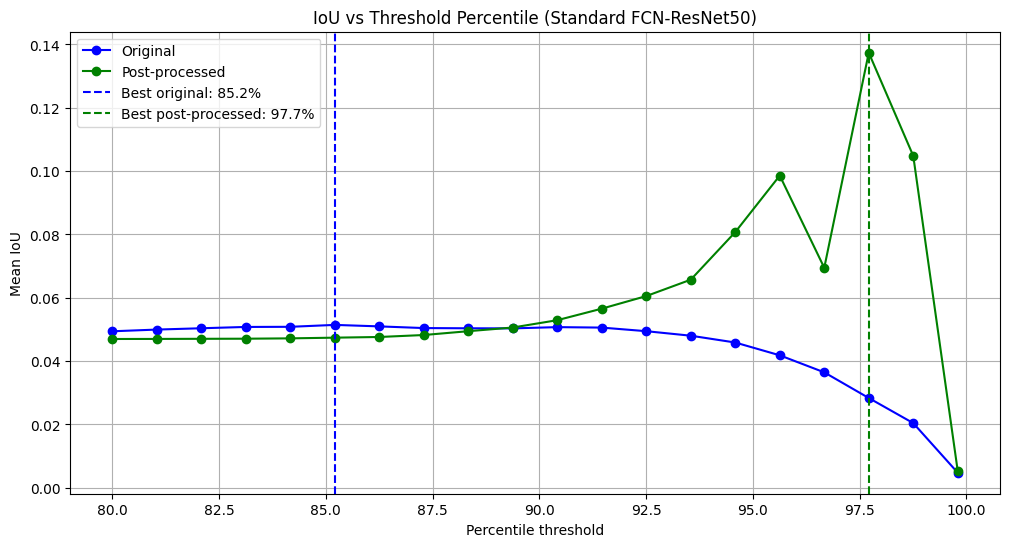

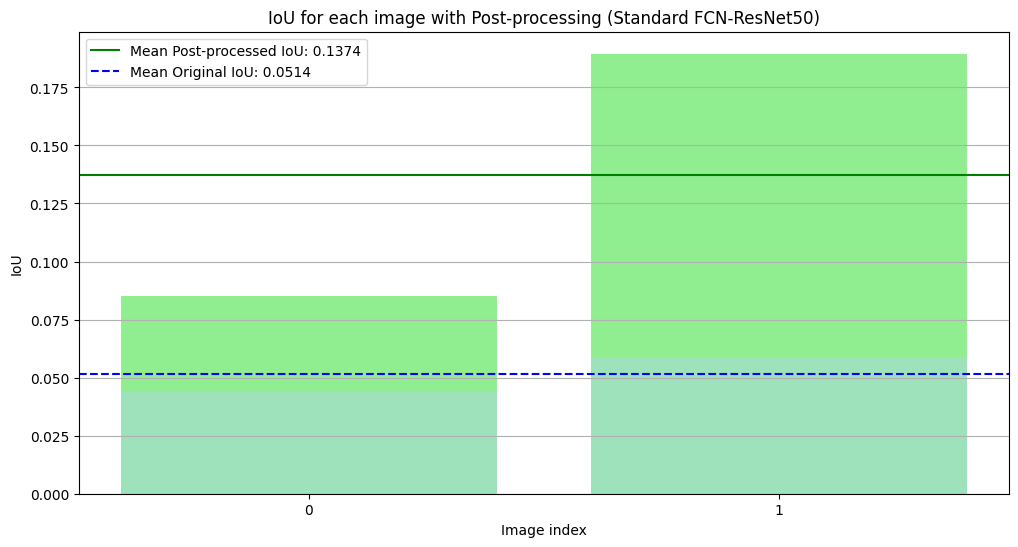

Percentile 80.0%: Mean IoU = 0.0396, Post-processed IoU = 0.0469
Percentile 81.0%: Mean IoU = 0.0397, Post-processed IoU = 0.0469
Percentile 82.1%: Mean IoU = 0.0396, Post-processed IoU = 0.0469
Percentile 83.1%: Mean IoU = 0.0403, Post-processed IoU = 0.0470
Percentile 84.2%: Mean IoU = 0.0403, Post-processed IoU = 0.0470
Percentile 85.2%: Mean IoU = 0.0400, Post-processed IoU = 0.0470
Percentile 86.3%: Mean IoU = 0.0400, Post-processed IoU = 0.0470
Percentile 87.3%: Mean IoU = 0.0399, Post-processed IoU = 0.0470
Percentile 88.3%: Mean IoU = 0.0397, Post-processed IoU = 0.0470
Percentile 89.4%: Mean IoU = 0.0405, Post-processed IoU = 0.0471
Percentile 90.4%: Mean IoU = 0.0408, Post-processed IoU = 0.0472
Percentile 91.5%: Mean IoU = 0.0410, Post-processed IoU = 0.0477
Percentile 92.5%: Mean IoU = 0.0419, Post-processed IoU = 0.0489
Percentile 93.5%: Mean IoU = 0.0431, Post-processed IoU = 0.0522
Percentile 94.6%: Mean IoU = 0.0428, Post-processed IoU = 0.0603
Percentile 95.6%: Mean Io

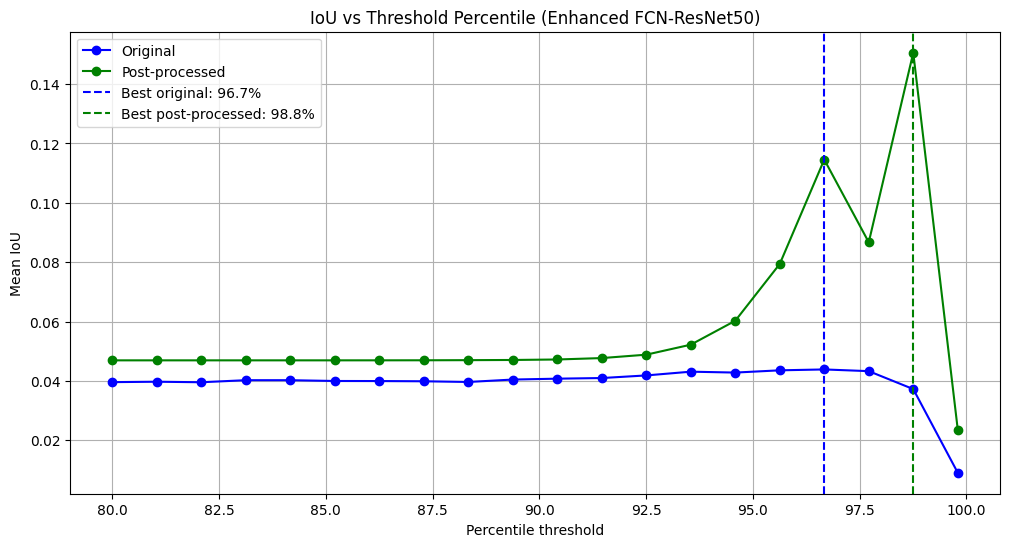

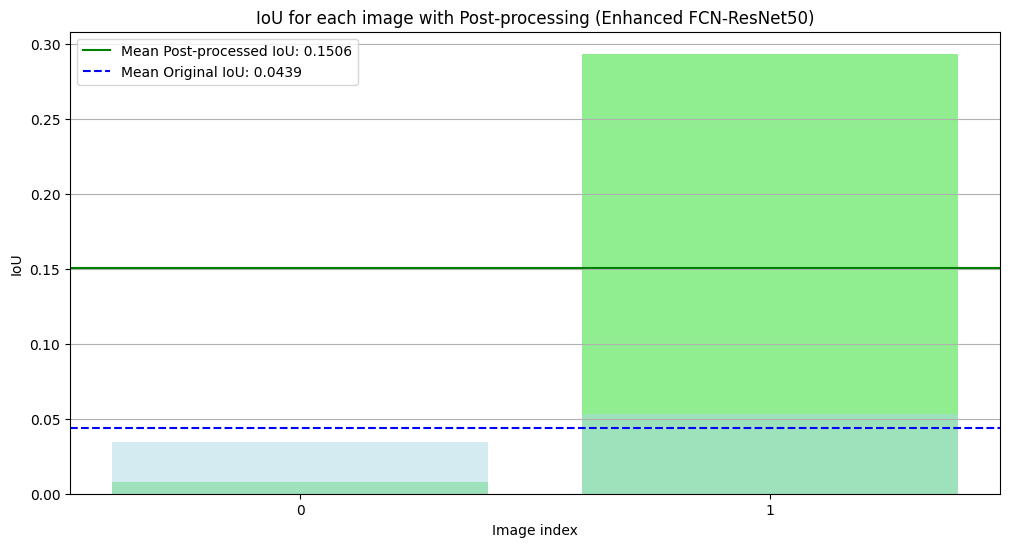

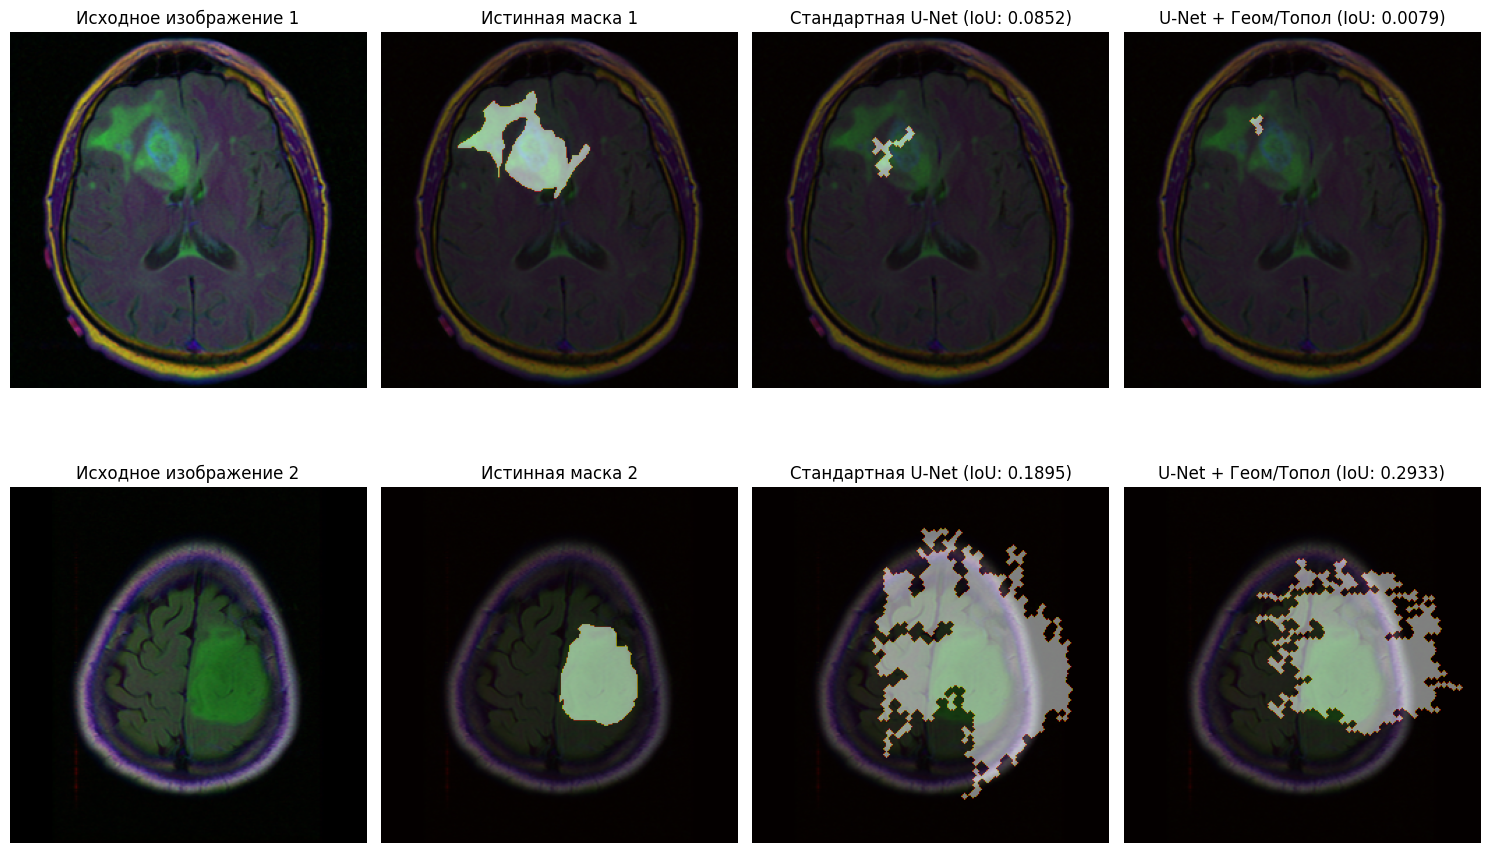

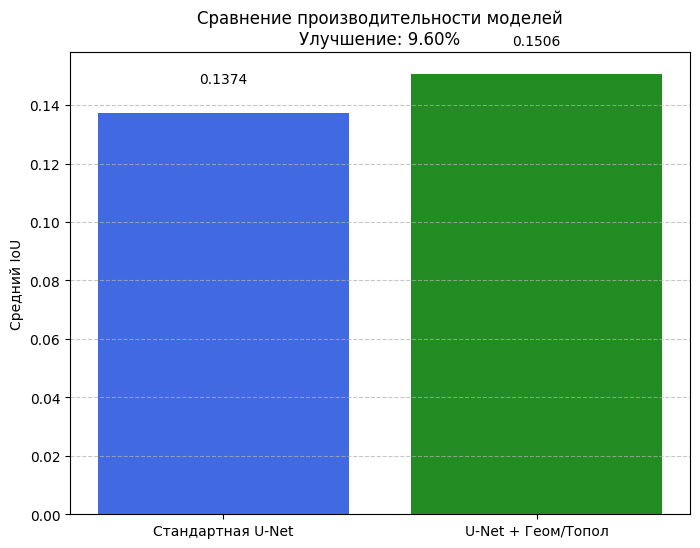

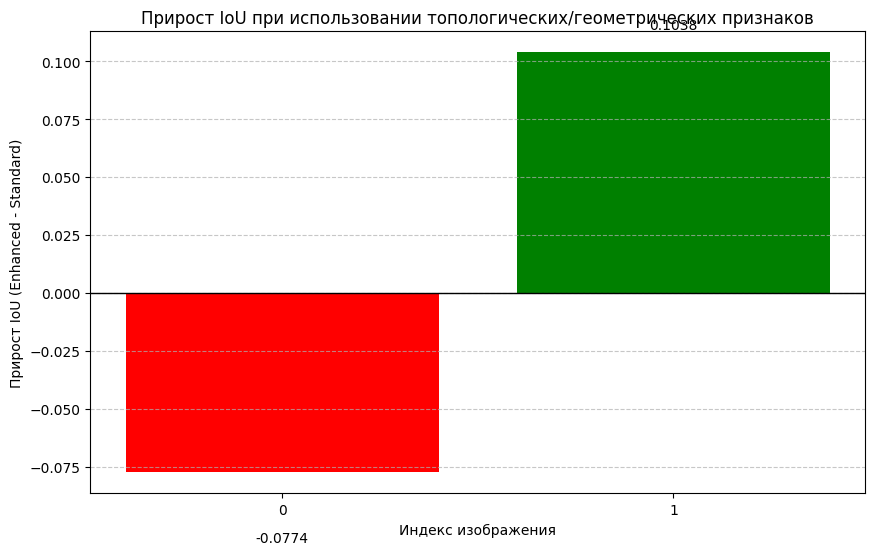


=== Training DeepLabV3 Models ===
Training Standard DeepLabV3


Epoch 1/1 (Val): 100%|██████████| 1/1 [00:00<00:00,  5.28it/s]


Epoch 1/1 - Train Loss: 0.9541, Val Loss: 0.9416
Saved best model with IoU score: 0.0474
Training Enhanced DeepLabV3


Epoch 1/1 (Val): 100%|██████████| 1/1 [00:00<00:00,  5.89it/s]


Epoch 1/1 - Train Loss: 0.9559, Val Loss: 0.9658
Saved best model with IoU score: 0.0144
Optimizing thresholds for DeepLabV3
Percentile 80.0%: Mean IoU = 0.1797, Post-processed IoU = 0.1723
Percentile 81.0%: Mean IoU = 0.1858, Post-processed IoU = 0.1783
Percentile 82.1%: Mean IoU = 0.1923, Post-processed IoU = 0.1848
Percentile 83.1%: Mean IoU = 0.2002, Post-processed IoU = 0.1922
Percentile 84.2%: Mean IoU = 0.2091, Post-processed IoU = 0.2004
Percentile 85.2%: Mean IoU = 0.2194, Post-processed IoU = 0.2099
Percentile 86.3%: Mean IoU = 0.2312, Post-processed IoU = 0.2208
Percentile 87.3%: Mean IoU = 0.2437, Post-processed IoU = 0.2320
Percentile 88.3%: Mean IoU = 0.2539, Post-processed IoU = 0.2425
Percentile 89.4%: Mean IoU = 0.2619, Post-processed IoU = 0.2487
Percentile 90.4%: Mean IoU = 0.2761, Post-processed IoU = 0.2596
Percentile 91.5%: Mean IoU = 0.2978, Post-processed IoU = 0.2800
Percentile 92.5%: Mean IoU = 0.3223, Post-processed IoU = 0.3063
Percentile 93.5%: Mean IoU = 0

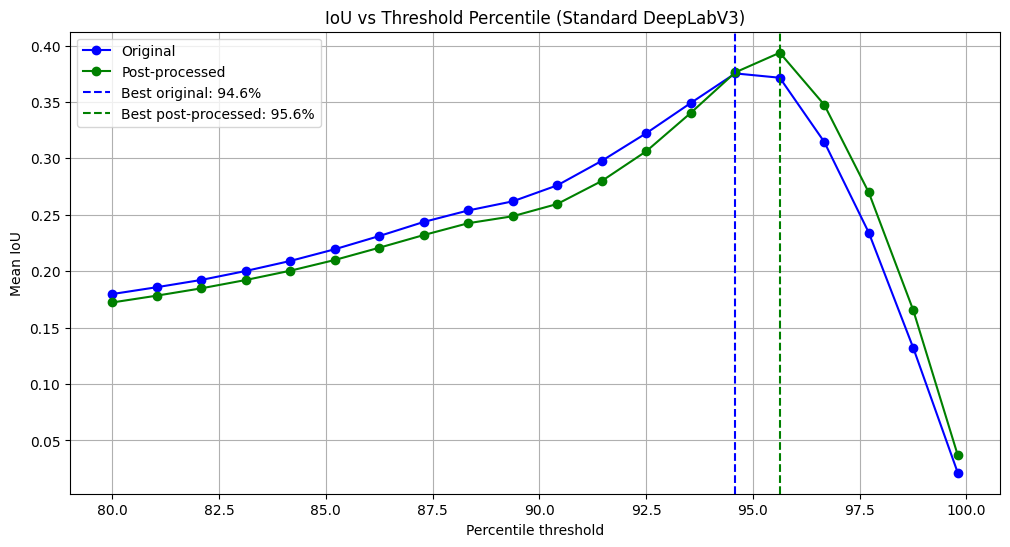

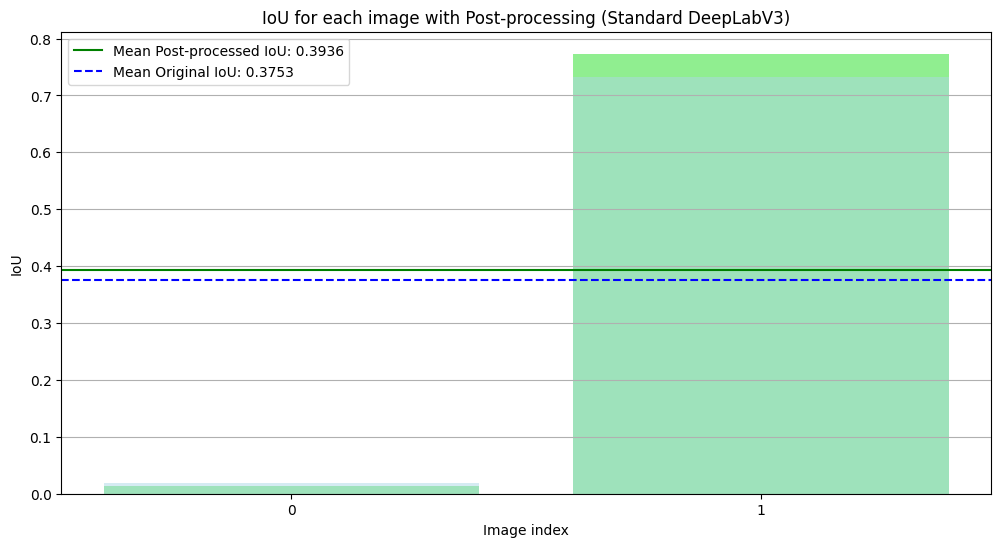

Percentile 80.0%: Mean IoU = 0.1728, Post-processed IoU = 0.1667
Percentile 81.0%: Mean IoU = 0.1801, Post-processed IoU = 0.1736
Percentile 82.1%: Mean IoU = 0.1879, Post-processed IoU = 0.1809
Percentile 83.1%: Mean IoU = 0.1964, Post-processed IoU = 0.1890
Percentile 84.2%: Mean IoU = 0.2057, Post-processed IoU = 0.1978
Percentile 85.2%: Mean IoU = 0.2161, Post-processed IoU = 0.2078
Percentile 86.3%: Mean IoU = 0.2282, Post-processed IoU = 0.2190
Percentile 87.3%: Mean IoU = 0.2413, Post-processed IoU = 0.2316
Percentile 88.3%: Mean IoU = 0.2542, Post-processed IoU = 0.2457
Percentile 89.4%: Mean IoU = 0.2664, Post-processed IoU = 0.2586
Percentile 90.4%: Mean IoU = 0.2793, Post-processed IoU = 0.2714
Percentile 91.5%: Mean IoU = 0.2857, Post-processed IoU = 0.2835
Percentile 92.5%: Mean IoU = 0.2786, Post-processed IoU = 0.2858
Percentile 93.5%: Mean IoU = 0.2666, Post-processed IoU = 0.2766
Percentile 94.6%: Mean IoU = 0.2521, Post-processed IoU = 0.2633
Percentile 95.6%: Mean Io

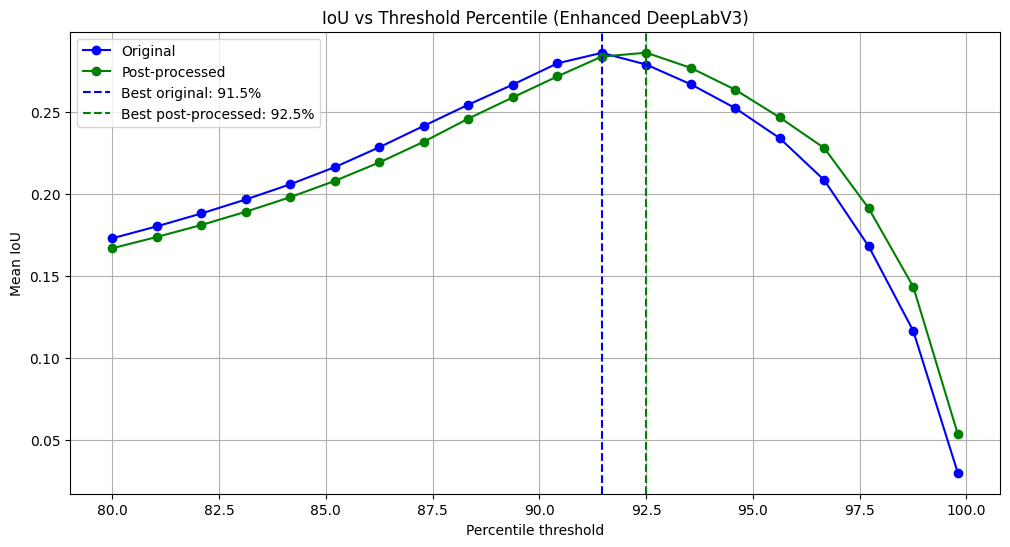

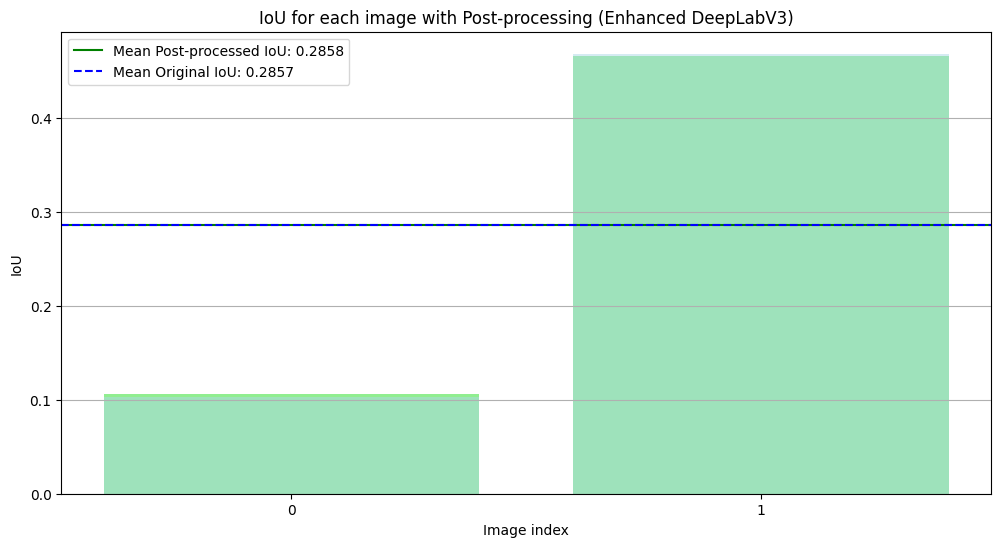

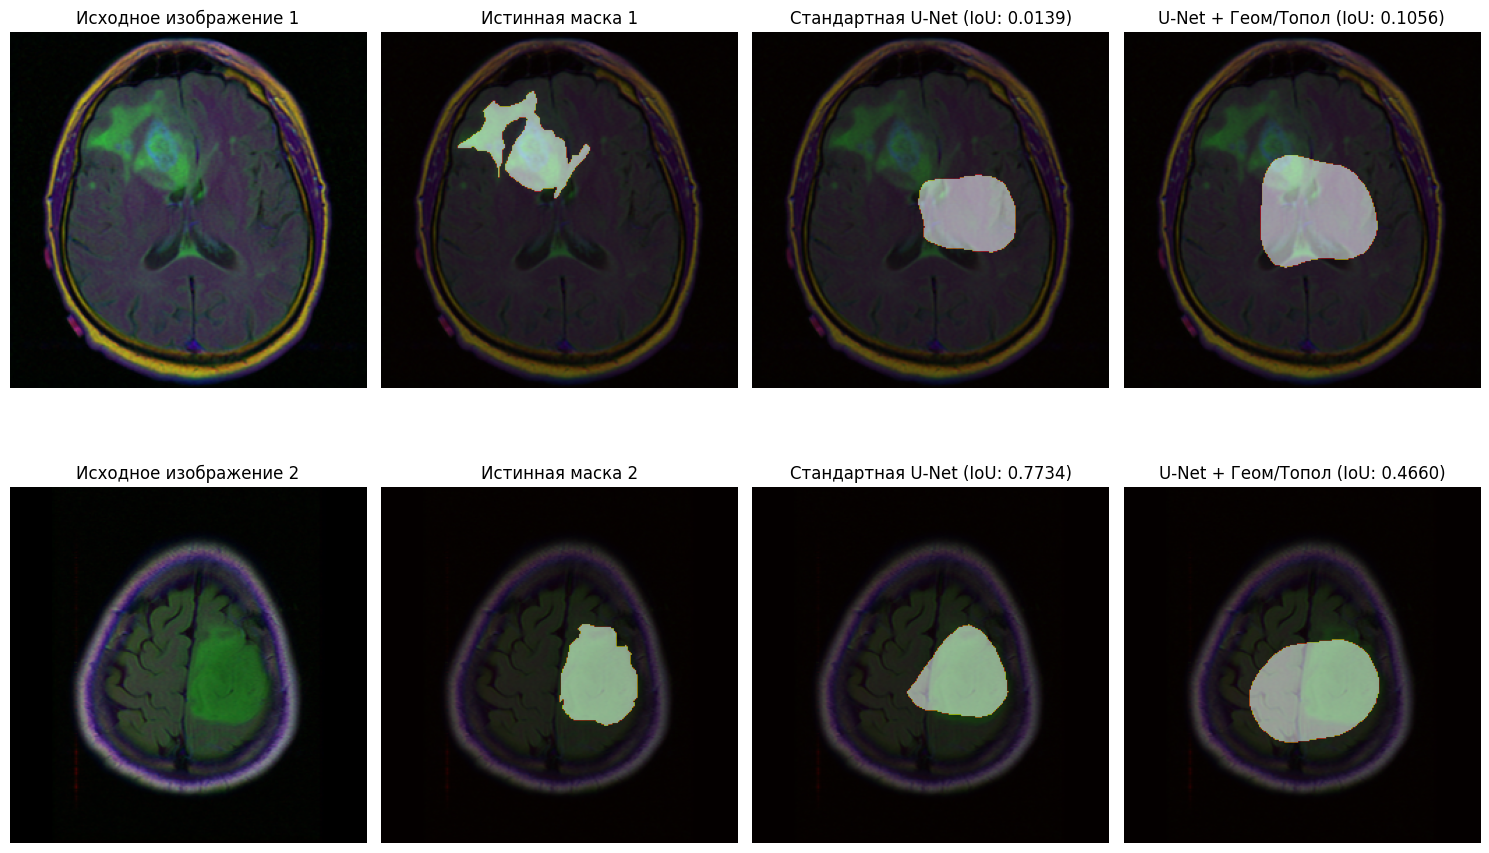

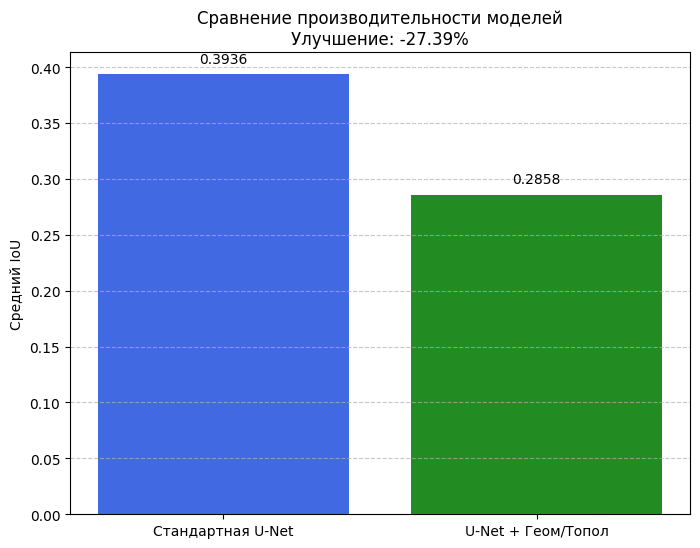

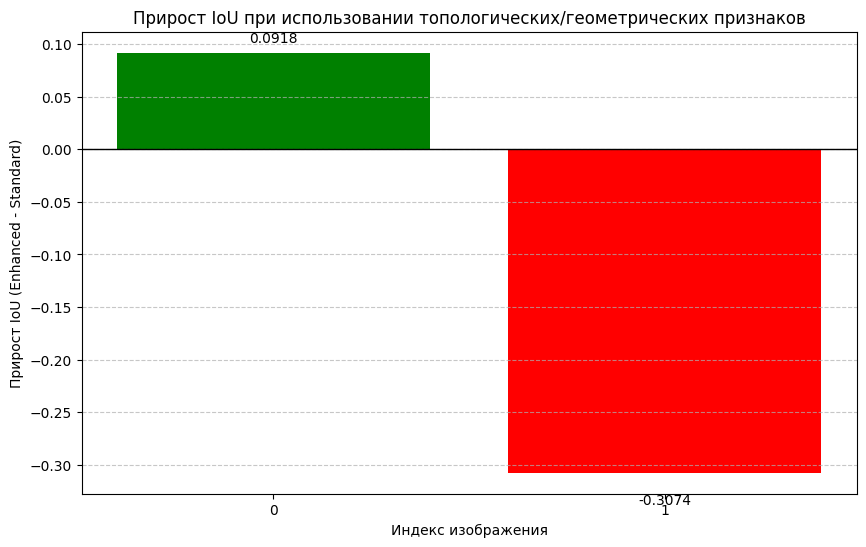


=== Summary of Results ===
Model           | Standard IoU    | Enhanced IoU    | Improvement (%)
-----------------------------------------------------------------
FCN-ResNet50    | 0.1374          | 0.1506          | 9.60           
DeepLabV3       | 0.3936          | 0.2858          | -27.39         


In [13]:
class FCNResNet50(nn.Module):
    """FCN с бэкбоном ResNet50"""
    def __init__(self, in_channels=3, out_channels=1):
        super(FCNResNet50, self).__init__()
        # Загружаем предобученную модель ResNet50 без полносвязных слоев
        self.backbone = models.resnet50(pretrained=True)
        
        # Удаляем последний полносвязный слой
        modules = list(self.backbone.children())[:-2]
        self.backbone = nn.Sequential(*modules)
        
        # Адаптируем входной слой для работы с нужным числом каналов
        if in_channels != 3:
            self.backbone[0] = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        # Добавляем upsampling слои
        self.upsample1 = nn.ConvTranspose2d(2048, 1024, kernel_size=2, stride=2)
        self.upsample2 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.upsample3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.upsample4 = nn.ConvTranspose2d(256, 64, kernel_size=2, stride=2)
        self.upsample5 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        
        # Выходной слой
        self.final = nn.Conv2d(32, out_channels, kernel_size=1)
        
    def forward(self, x):
        input_size = x.size()
        
        # Получаем признаки из бэкбона
        x = self.backbone(x)
        
        # Увеличиваем разрешение
        x = self.upsample1(x)
        x = F.relu(x)
        
        x = self.upsample2(x)
        x = F.relu(x)
        
        x = self.upsample3(x)
        x = F.relu(x)
        
        x = self.upsample4(x)
        x = F.relu(x)
        
        x = self.upsample5(x)
        x = F.relu(x)
        
        # Подгоняем выходное разрешение к входному
        x = F.interpolate(x, size=(input_size[2], input_size[3]), mode='bilinear', align_corners=False)
        
        # Финальный слой
        x = self.final(x)
        return torch.sigmoid(x)

class EnhancedFCNResNet50(nn.Module):
    """FCN с бэкбоном ResNet50 и дополнительной обработкой геометрических/топологических признаков"""
    def __init__(self, in_channels=3, feature_channels=1, out_channels=1):
        super(EnhancedFCNResNet50, self).__init__()
        # Загружаем предобученную модель ResNet50 для основного изображения
        self.backbone = models.resnet50(pretrained=True)
        modules = list(self.backbone.children())[:-2]
        self.backbone = nn.Sequential(*modules)
        
        # Адаптируем входной слой для работы с нужным числом каналов
        if in_channels != 3:
            self.backbone[0] = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        # Создаем отдельную ветвь для обработки геометрических/топологических признаков
        self.feature_conv1 = nn.Conv2d(feature_channels, 32, kernel_size=3, padding=1)
        self.feature_bn1 = nn.BatchNorm2d(32)
        self.feature_conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.feature_bn2 = nn.BatchNorm2d(64)
        self.feature_pool1 = nn.MaxPool2d(2)
        self.feature_conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.feature_bn3 = nn.BatchNorm2d(128)
        self.feature_pool2 = nn.MaxPool2d(2)
        self.feature_conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.feature_bn4 = nn.BatchNorm2d(256)
        self.feature_pool3 = nn.MaxPool2d(2)
        self.feature_conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.feature_bn5 = nn.BatchNorm2d(512)
        self.feature_pool4 = nn.MaxPool2d(2)
        self.feature_conv6 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)
        self.feature_bn6 = nn.BatchNorm2d(1024)
        self.feature_pool5 = nn.MaxPool2d(2)
        
        # Upsampling слои
        self.upsample1 = nn.ConvTranspose2d(2048 + 1024, 1024, kernel_size=2, stride=2)
        self.upsample2 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.upsample3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.upsample4 = nn.ConvTranspose2d(256, 64, kernel_size=2, stride=2)
        self.upsample5 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        
        # Выходной слой
        self.final = nn.Conv2d(32, out_channels, kernel_size=1)
        
    def forward(self, x, features):
        input_size = x.size()
        
        # Обработка основного изображения
        x = self.backbone(x)
        
        # Обработка геометрических/топологических признаков
        f = F.relu(self.feature_bn1(self.feature_conv1(features)))
        f = F.relu(self.feature_bn2(self.feature_conv2(f)))
        f = self.feature_pool1(f)
        f = F.relu(self.feature_bn3(self.feature_conv3(f)))
        f = self.feature_pool2(f)
        f = F.relu(self.feature_bn4(self.feature_conv4(f)))
        f = self.feature_pool3(f)
        f = F.relu(self.feature_bn5(self.feature_conv5(f)))
        f = self.feature_pool4(f)
        f = F.relu(self.feature_bn6(self.feature_conv6(f)))
        f = self.feature_pool5(f)
        
        # Адаптируем размерность геометрических признаков к основным
        f = F.interpolate(f, size=(x.size(2), x.size(3)), mode='bilinear', align_corners=False)
        
        # Объединяем признаки
        x = torch.cat([x, f], dim=1)
        
        # Увеличиваем разрешение
        x = self.upsample1(x)
        x = F.relu(x)
        
        x = self.upsample2(x)
        x = F.relu(x)
        
        x = self.upsample3(x)
        x = F.relu(x)
        
        x = self.upsample4(x)
        x = F.relu(x)
        
        x = self.upsample5(x)
        x = F.relu(x)
        
        # Подгоняем выходное разрешение к входному
        x = F.interpolate(x, size=(input_size[2], input_size[3]), mode='bilinear', align_corners=False)
        
        # Финальный слой
        x = self.final(x)
        return torch.sigmoid(x)

class DeepLabV3(nn.Module):
    """DeepLabV3 с бэкбоном ResNet50"""
    def __init__(self, in_channels=3, out_channels=1):
        super(DeepLabV3, self).__init__()
        # Загружаем предобученную модель DeepLabV3
        self.model = models.segmentation.deeplabv3_resnet50(pretrained=True)
        
        # Адаптируем входной слой для работы с нужным числом каналов
        if in_channels != 3:
            self.model.backbone.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        # Адаптируем выходной слой для работы с нужным числом классов
        self.model.classifier[4] = nn.Conv2d(256, out_channels, kernel_size=1)
        
    def forward(self, x):
        x = self.model(x)['out']
        return torch.sigmoid(x)

class EnhancedDeepLabV3(nn.Module):
    """DeepLabV3 с бэкбоном ResNet50 и дополнительной обработкой геометрических/топологических признаков"""
    def __init__(self, in_channels=3, feature_channels=1, out_channels=1):
        super(EnhancedDeepLabV3, self).__init__()
        # Загружаем предобученную модель DeepLabV3
        self.model = models.segmentation.deeplabv3_resnet50(pretrained=True, num_classes=21)
        
        # Адаптируем входной слой для работы с нужным числом каналов
        if in_channels != 3:
            self.model.backbone.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        # Заменяем выходной слой на свой
        self.model.classifier[4] = nn.Conv2d(256, 256, kernel_size=1)
        
        # Создаем отдельную ветвь для обработки геометрических/топологических признаков
        self.feature_path = nn.Sequential(
            nn.Conv2d(feature_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        
        # Интеграция геометрических признаков в выходной слой
        self.fusion = nn.Conv2d(256 + 256, 256, kernel_size=3, padding=1)
        self.classifier = nn.Conv2d(256, out_channels, kernel_size=1)
        
    def forward(self, x, features):
        # Получаем промежуточный результат из DeepLabV3 (до финальной классификации)
        # используем интерфейс для .backbone и .classifier отдельно
        x_size = x.size()
        features_backbone = self.model.backbone(x)
        x = self.model.classifier(features_backbone['out'])
        
        # Обработка геометрических/топологических признаков
        f = self.feature_path(features)
        
        # Адаптируем размерность геометрических признаков к основным
        f = F.interpolate(f, size=(x.size(2), x.size(3)), mode='bilinear', align_corners=False)
        
        # Объединяем признаки
        x = torch.cat([x, f], dim=1)
        x = self.fusion(x)
        x = self.classifier(x)
        
        # Масштабируем до исходного размера
        x = F.interpolate(x, size=(x_size[2], x_size[3]), mode='bilinear', align_corners=False)
        
        return torch.sigmoid(x)


# 2. Функция для обучения и сравнения всех моделей

def compare_models(tumor_images, true_masks, feature_maps, num_epochs=25, device='cuda'):
    # Разделение данных на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test, f_train, f_test = train_test_split(
        tumor_images, true_masks, feature_maps, test_size=0.3, random_state=SEED
    )
    
    X_train, X_val, y_train, y_val, f_train, f_val = train_test_split(
        X_train, y_train, f_train, test_size=0.2, random_state=SEED
    )
    
    print(f"Training: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")
    
    # Создание датасетов
    train_dataset = BrainTumorDataset(X_train, y_train)
    val_dataset = BrainTumorDataset(X_val, y_val)
    test_dataset = BrainTumorDataset(X_test, y_test)
    
    enhanced_train_dataset = EnhancedBrainTumorDataset(X_train, f_train, y_train)
    enhanced_val_dataset = EnhancedBrainTumorDataset(X_val, f_val, y_val)
    enhanced_test_dataset = EnhancedBrainTumorDataset(X_test, f_test, y_test)
    
    # Создание загрузчиков данных
    batch_size = 4
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=1)
    
    enhanced_train_loader = DataLoader(enhanced_train_dataset, batch_size=batch_size, shuffle=True)
    enhanced_val_loader = DataLoader(enhanced_val_dataset, batch_size=batch_size)
    enhanced_test_loader = DataLoader(enhanced_test_dataset, batch_size=1)
    
    # Определение моделей
    learning_rate = 0.001

    
    # 2. FCN с ResNet50
    standard_fcn = FCNResNet50(in_channels=3, out_channels=1)
    enhanced_fcn = EnhancedFCNResNet50(in_channels=3, feature_channels=1, out_channels=1)
    
    # 3. DeepLabV3
    standard_deeplab = DeepLabV3(in_channels=3, out_channels=1)
    enhanced_deeplab = EnhancedDeepLabV3(in_channels=3, feature_channels=1, out_channels=1)
    
    # Словарь с моделями для обучения
    models_to_train = {
        "FCN-ResNet50": (standard_fcn, enhanced_fcn),
        "DeepLabV3": (standard_deeplab, enhanced_deeplab)
    }
    
    # Результаты для сравнения
    results = {}
    
    # Обучение и оценка каждой пары моделей
    for model_name, (standard_model, enhanced_model) in models_to_train.items():
        print(f"\n=== Training {model_name} Models ===")
        
        # Обучение стандартной модели
        print(f"Training Standard {model_name}")
        optimizer = optim.Adam(standard_model.parameters(), lr=learning_rate)
        standard_model, _ = train_model(
            standard_model, train_loader, val_loader, dice_loss, optimizer, 
            num_epochs=num_epochs, device=device, is_enhanced=False
        )
        
        # Обучение расширенной модели
        print(f"Training Enhanced {model_name}")
        optimizer = optim.Adam(enhanced_model.parameters(), lr=learning_rate)
        enhanced_model, _ = train_model(
            enhanced_model, enhanced_train_loader, enhanced_val_loader, dice_loss, optimizer, 
            num_epochs=num_epochs, device=device, is_enhanced=True
        )
        
        # Получение предсказаний стандартной модели
        standard_predictions = []
        standard_model.eval()
        with torch.no_grad():
            for batch in test_loader:
                images = batch['image'].to(device)
                outputs = standard_model(images)
                standard_predictions.append(outputs.cpu().numpy()[0, 0])
        
        # Получение предсказаний расширенной модели
        enhanced_predictions = []
        enhanced_model.eval()
        with torch.no_grad():
            for batch in enhanced_test_loader:
                images = batch['image'].to(device)
                features = batch['features'].to(device)
                outputs = enhanced_model(images, features)
                enhanced_predictions.append(outputs.cpu().numpy()[0, 0])
        
        # Оптимизация порогов и вычисление IoU
        print(f"Optimizing thresholds for {model_name}")
        standard_best_percentile, standard_best_iou, standard_best_masks, standard_image_ious = evaluate_thresholds_and_plot(
            standard_predictions, y_test, percentile_range=(80, 99.8), num_steps=20, 
            model_name=f"Standard {model_name}", with_postprocessing=True
        )
        
        enhanced_best_percentile, enhanced_best_iou, enhanced_best_masks, enhanced_image_ious = evaluate_thresholds_and_plot(
            enhanced_predictions, y_test, percentile_range=(80, 99.8), num_steps=20, 
            model_name=f"Enhanced {model_name}", with_postprocessing=True
        )
        
        # Сохранение результатов
        results[model_name] = {
            "standard_iou": standard_best_iou,
            "enhanced_iou": enhanced_best_iou,
            "improvement": (enhanced_best_iou - standard_best_iou) / standard_best_iou * 100,
            "standard_masks": standard_best_masks,
            "enhanced_masks": enhanced_best_masks,
            "standard_image_ious": standard_image_ious,
            "enhanced_image_ious": enhanced_image_ious
        }
        
        # Визуализация сравнения только для текущей модели
        visualize_comparison(
            X_test, y_test, 
            standard_best_masks, enhanced_best_masks,
            standard_image_ious, enhanced_image_ious
        )
    
    # Сводная таблица результатов
    print("\n=== Summary of Results ===")
    print(f"{'Model':<15} | {'Standard IoU':<15} | {'Enhanced IoU':<15} | {'Improvement (%)':<15}")
    print("-" * 65)
    for model_name, result in results.items():
        print(f"{model_name:<15} | {result['standard_iou']:<15.4f} | {result['enhanced_iou']:<15.4f} | {result['improvement']:<15.2f}")
    
    return results

# 3. Основной блок кода
if __name__ == "__main__":
    SEED = 42
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {DEVICE}")
    
    # Загрузка данных и вычисление признаков
    base_path = "/Users/dasidorov03/PycharmProjects/dploma_4_course/RSNA-ASNR-MICCAI/brain_tumor_custom"
    tumor_images, true_masks = load_custom_dataset(base_path, max_samples=5)  # Уменьшено для ускорения
    
    print(f"Loaded {len(tumor_images)} images")
    
    print("Computing geometric/topological features...")
    feature_maps = compute_fiber_bundle_features(
        tumor_images,
        patch_size=6,
        stride=5,
        n_neighbors=5
    )
    
    # Запуск сравнения моделей
    num_epochs = 1  # Уменьшено для ускорения
    results = compare_models(tumor_images, true_masks, feature_maps, num_epochs=num_epochs, device=DEVICE)
